In [ ]:
!pip install transformers datasets kagglehub scikit-learn nltk seaborn

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
import re
import nltk
import torch
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
import matplotlib.pyplot as plt
import seaborn as sns
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
path = kagglehub.dataset_download("naserabdullahalam/phishing-email-dataset")
print("Dataset path:", path)

Using Colab cache for faster access to the 'phishing-email-dataset' dataset.
Dataset path: /kaggle/input/phishing-email-dataset


In [ ]:
dfs = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            dfs.append(pd.read_csv(os.path.join(root, file)))
df = pd.concat(dfs, ignore_index=True)
print("Columns:", df.columns)

Columns: Index(['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls',
       'text_combined'],
      dtype='object')


In [ ]:
df['text'] = df['text_combined']
if df['label'].dtype == 'object':
    df['label'] = df['label'].map({
        'phishing': 1,
        'legitimate': 0
    })
df = df[['text', 'label']].dropna()
print("Total samples:", len(df))
print(df['label'].value_counts())

Total samples: 82486
label
1    42891
0    39595
Name: count, dtype: int64


In [ ]:
df = df.sample(10000, random_state=42)

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', 'url', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text
df['clean_text'] = df['text'].apply(clean_text)

In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['clean_text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)
train_dataset = EmailDataset(train_encodings, train_labels)
test_dataset = EmailDataset(test_encodings, test_labels)

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,                  # fast
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_dir='./logs',
    save_strategy="no"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir='./logs'
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [ ]:
trainer.train()

Step,Training Loss
500,0.154401


TrainOutput(global_step=500, training_loss=0.15440145874023437, metrics={'train_runtime': 92.5756, 'train_samples_per_second': 86.416, 'train_steps_per_second': 5.401, 'total_flos': 264934797312000.0, 'train_loss': 0.15440145874023437, 'epoch': 1.0})

In [ ]:
preds = trainer.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=1)
print("\nClassification Report:\n")
print(classification_report(test_labels, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       994
           1       0.98      0.98      0.98      1006

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



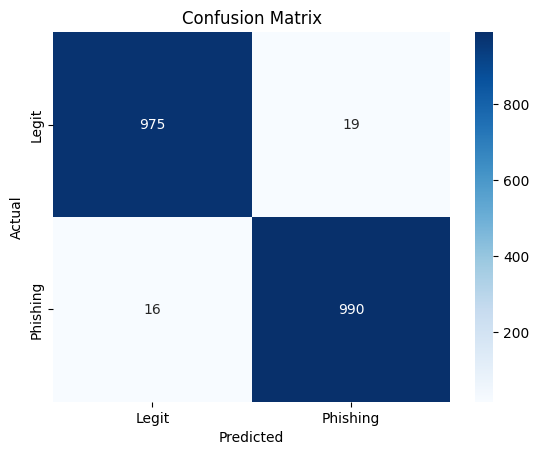

In [ ]:
cm = confusion_matrix(test_labels, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Phishing'],
            yticklabels=['Legit', 'Phishing'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(test_labels, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9825


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def predict_email(text):
    text = clean_text(text)
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
    phishing_prob = probs[0][1].item()
    label = "Phishing" if phishing_prob > 0.5 else "Legitimate"
    return label, phishing_prob

In [ ]:
print("Sample Prediction:")
print(predict_email("Your account has been suspended. Click here to verify immediately"))

Sample Prediction:
('Phishing', 0.7126232981681824)
